# The HSV Color Space

Welcome to Module 2 of the Computer Vision Specialization! In this first notebook, we will explore a very useful and intuitive color space: HSV (Hue, Saturation, Value).

One of the great advantages of working with the HSV color space is the ease of manipulating specific color 'channels.' This can be very helpful for various image processing tasks, such as identifying the dominant color in an image or segmenting objects by color.

Throughout this notebook, we will delve deeper into the HSV color space and experiment with several useful image processing techniques that leverage this color space.


## Understanding the HSV Color Space

When working with digital images, the color space is an essential component. In many cases, the RGB color space (Red, Green, and Blue) is the most commonly used. However, it is not very intuitive for us humans. This is where the HSV color space comes in.

The HSV color space is closer to how humans perceive color, making it an intuitive color space to work with. It is represented by a cylindrical coordinate system:

* **Hue:** This is the angle in the cylindrical coordinate system and represents the "pure" color. It ranges from 0 to 180 in software like OpenCV, but can range from 0 to 360 in other contexts.
* **Saturation:** This is the radial axis in the cylindrical coordinate system. Saturation represents the "purity" of the color, ranging from 0 (no color, shades of gray) to 255 (pure color).
* **Value:** This is the vertical axis in the cylindrical coordinate system. Value represents the brightness of the color, ranging from 0 (black) to 255 (white).

In the HSV color space, the Hue component represents the dominant wavelength of light, varying between 0 and 360 degrees. Saturation, on the other hand, represents the purity (or intensity) of a color. A higher saturation value indicates a more vivid and vibrant color, while a lower value represents a more faded or pastel-like color. Finally, the Value component represents the brightness or luminance of a color. A higher value corresponds to a brighter color, while a lower value represents a darker color.

An important note is that in OpenCV, the Hue values range from 0 to 180, while Saturation and Value are in the range of 0 to 255. This means that in OpenCV, Hue values 179, 178, 177, and so on are as close to true RED as Hue values 1, 2, 3.

Understanding these nuances of the HSV color space, especially as implemented in OpenCV, can aid in various computer vision and image processing applications. It offers a more robust way to manipulate colors and achieve desired effects compared to the traditional RGB color space.



In [1]:
# Importing libraries
import numpy as np
import cv2
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib import colors
import plotly.express as px
import matplotlib.pyplot as plt
from pathlib import Path

matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
matplotlib.rcParams['image.cmap'] = 'gray'

%matplotlib inline

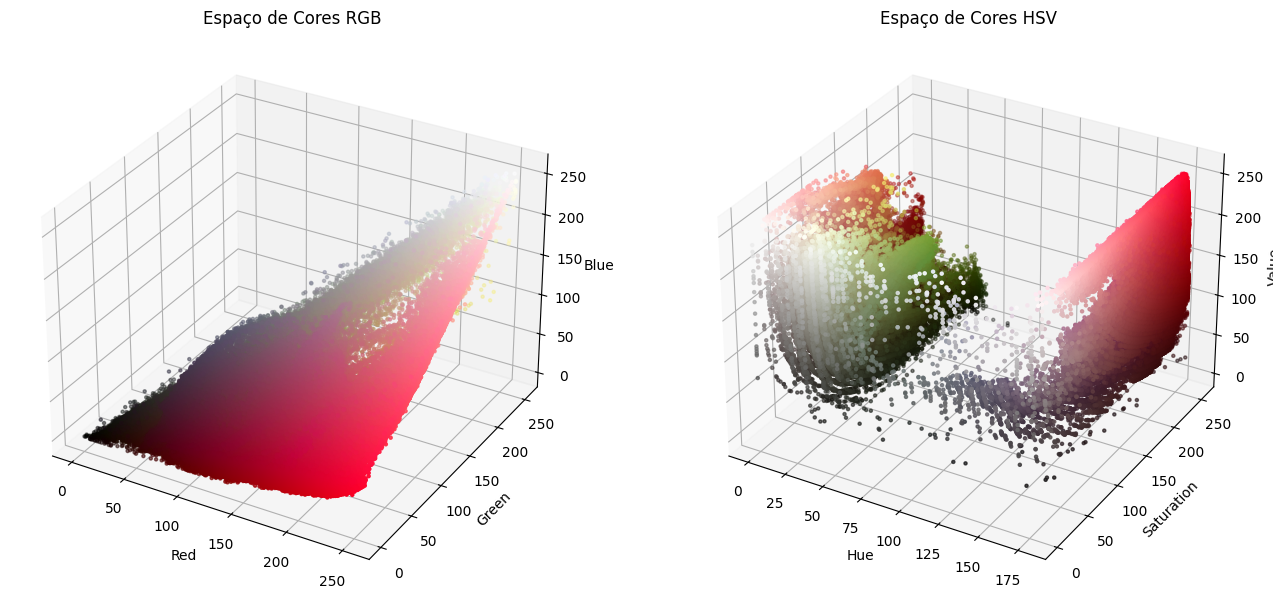

In [ ]:
# Apple image
apple_path = Path.cwd().parent.parent / "data" / "apple.jpg"
apple = cv2.imread(apple_path)
apple = cv2.cvtColor(apple, cv2.COLOR_BGR2RGB)

r, g, b = cv2.split(apple)

fig = plt.figure(figsize=(16, 8))

# Plot RGB
axis_rgb = fig.add_subplot(1, 2, 1, projection="3d")
pixel_colors = apple.reshape((np.shape(apple)[0] * np.shape(apple)[1], 3))
norm = colors.Normalize(vmin=-1., vmax=1.)
norm.autoscale(pixel_colors)
pixel_colors = norm(pixel_colors).tolist()
axis_rgb.scatter(r.flatten(), g.flatten(), b.flatten(), facecolors=pixel_colors, marker=".")
axis_rgb.set_xlabel("Red")
axis_rgb.set_ylabel("Green")
axis_rgb.set_zlabel("Blue")
axis_rgb.set_title("Espaço de Cores RGB")

# to HSV
hsv_maca = cv2.cvtColor(apple, cv2.COLOR_RGB2HSV)
h, s, v = cv2.split(hsv_maca)

axis_hsv = fig.add_subplot(1, 2, 2, projection="3d")
axis_hsv.scatter(h.flatten(), s.flatten(), v.flatten(), facecolors=pixel_colors, marker=".")
axis_hsv.set_xlabel("Hue")
axis_hsv.set_ylabel("Saturation")
axis_hsv.set_zlabel("Value")
axis_hsv.set_title("Espaço de Cores HSV")

plt.show()


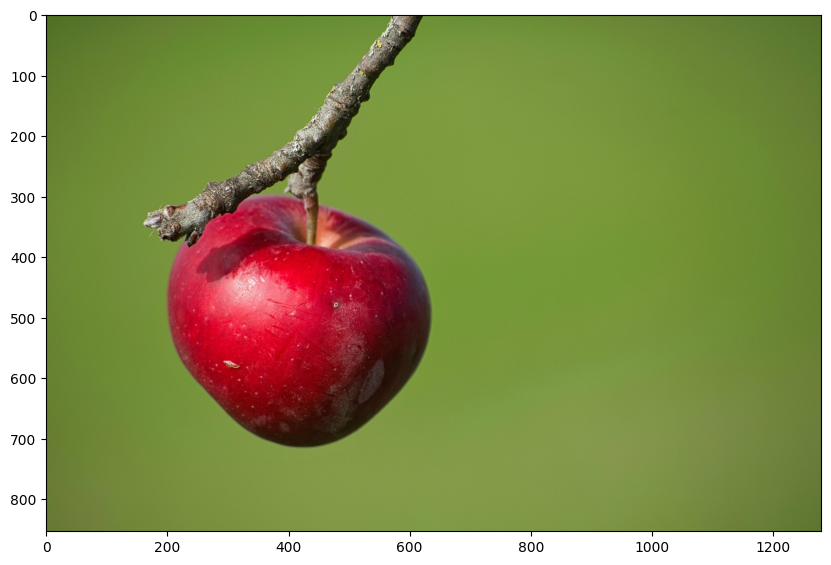

In [3]:
plt.imshow(apple)

As we can see in the code above, this section imports the necessary libraries for our task of finding the dominant color in an image.

- We import **`numpy`** for numerical operations,  
- **`cv2`** for computer vision functionalities, and  
- **`matplotlib.pyplot`** to visualize images and plots.

The `%matplotlib inline` command ensures that plots are displayed directly within the Jupyter Notebook or IPython environment.

The following lines configure parameters for displaying images and plots, such as:

- **Figure size**
- **Color map**
- **Interpolation method**

These settings help us visualize images and plots in the desired format.


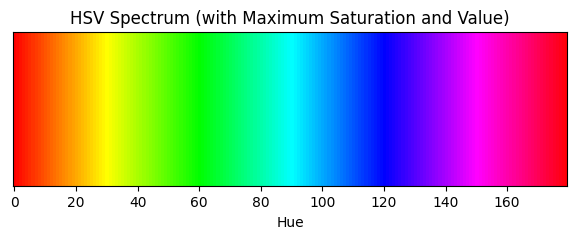

In [4]:
# Create a matrix of zeros to represent the HSV color space
hsv_spectrum = np.zeros((50, 180, 3), dtype=np.uint8)

# Set maximum saturation and value for the entire spectrum
hsv_spectrum[:,:,1] = 255  # Saturation
hsv_spectrum[:,:,2] = 255  # Value

# For each column, set the Hue equal to the column index
for i in range(180):
    hsv_spectrum[:,i,0] = i

# Convert the HSV image to RGB
rgb_spectrum = cv2.cvtColor(hsv_spectrum, cv2.COLOR_HSV2RGB)

# Create the plot
plt.figure(figsize=(10,2))  # you can adjust the size as needed
plt.imshow(rgb_spectrum)
plt.yticks([])  # Remove y-axis ticks
plt.xlabel("Hue")
plt.title("HSV Spectrum (with Maximum Saturation and Value)")

# Display the plot
plt.show()


Above, you can see that the provided code demonstrates how to create a color spectrum in the HSV color space. The code begins by creating a NumPy array of zeros to represent the HSV color space. The saturation and value channels are set to their maximum values across the entire spectrum. Then, for each column, the hue channel is set to the corresponding index value. Next, the HSV image is converted to RGB using the cv2.cvtColor() function. Finally, the RGB spectrum is displayed using plt.imshow(). The resulting plot shows the color spectrum in the HSV color space with maximum saturation and value.

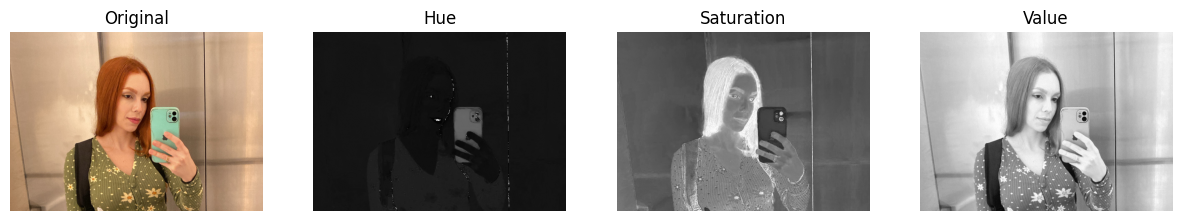

In [6]:
# Lê a imagem a partir do arquivo
path_img = Path.cwd().parent.parent / "data" / "carmen_01.jpg"
img = cv2.imread(path_img)
# Exibe a imagem original
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(img[...,::-1])
plt.title("Original")
plt.axis('off')

# Converte a imagem de BGR para HSV
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Para cada canal HSV, exibe sua respectiva imagem em escala de cinza
components = ['Hue', 'Saturation', 'Value']
for i in range(3):
    plt.subplot(1, 4, i+2)
    plt.imshow(hsv_img[:,:,i], cmap='gray')
    plt.title(f"{components[i]}")
    plt.axis('off')

### Visualizing HSV Channels from an Image

Let's take a closer look at what’s happening here. The code begins by reading an image from a file using the `cv2.imread()` function and storing it in the variable `img`.

Next, the original image is displayed using `plt.imshow()` with an appropriate title. The function `plt.subplot()` is used to create a grid of subplots.

For each channel of the HSV image (**Hue**, **Saturation**, and **Value**), a subplot is created to display the respective grayscale image using `plt.imshow()`. The argument `cmap='gray'` ensures that the channels are displayed in grayscale.

The titles of the subplots are set to the names of the HSV components. This snippet of code allows us to visualize the original image and its separated HSV components side by side.


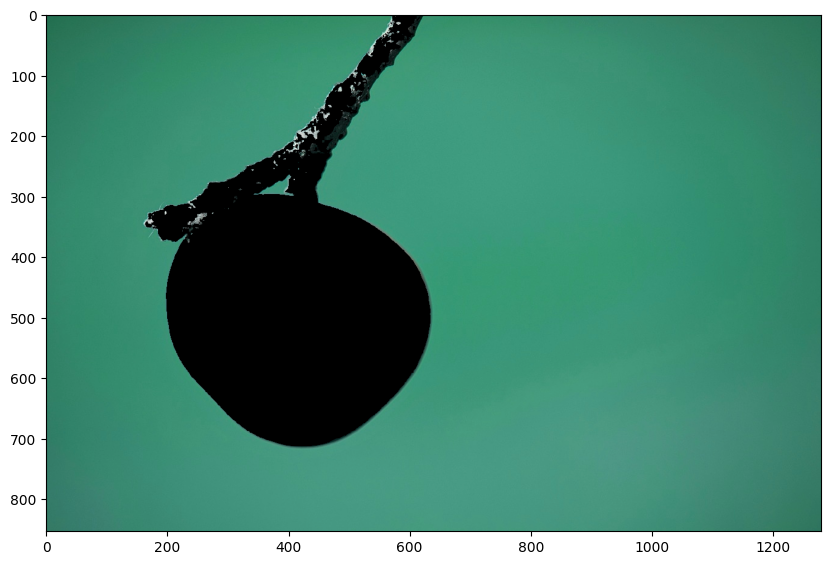

In [13]:
apple_hsv = cv2.cvtColor(apple, cv2.COLOR_BGR2HSV)

lower = np.array([30, 0, 0])
upper = np.array([90, 255, 255])

mask = cv2.inRange(apple_hsv, lower, upper)

res = cv2.bitwise_and(apple_hsv, apple_hsv, mask=mask)
res = cv2.cvtColor(res, cv2.COLOR_HSV2RGB)
plt.imshow(res);